# Notebook 03 — Feature Engineering & SMOTE

**Project**: Ethiopian Fintech Analytics Platform  
**Author**: Eyob Nebyou  
**Dataset**: Give Me Some Credit (cleaned from Notebook 01)  
**Goal**: Build new features, balance classes with SMOTE, and save the final feature store.

---

## What We're Doing

1. Load the cleaned data from EDA
2. Engineer domain-specific features
3. Encode categorical features
4. Apply SMOTE to fix the 14:1 class imbalance
5. Save the final feature store ready for model training

---

In [1]:
# ── Imports ────────────────────────────────────────────────────
import sys
import os
sys.path.append(os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
!{sys.executable} -m pip install imbalanced-learn

from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import LabelEncoder

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)
print('Libraries loaded successfully.')

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Libraries loaded successfully.


## 1. Load Cleaned Data

In [2]:
# ── Load the cleaned credit data from EDA ──────────────────────
# We re-load and re-apply the cleaning steps from Notebook 01
# so this notebook is fully self-contained

df = pd.read_csv('../data/raw/credit/cs-training.csv', index_col=0)
df.rename(columns={'SeriousDlqin2yrs': 'default_target'}, inplace=True)

# Re-apply cleaning from Notebook 01
df['MonthlyIncome'] = df['MonthlyIncome'].fillna(df['MonthlyIncome'].median())
df['NumberOfDependents'] = df['NumberOfDependents'].fillna(0)
df = df[(df['age'] >= 18) & (df['age'] <= 96)]
df['RevolvingUtilizationOfUnsecuredLines'] = df['RevolvingUtilizationOfUnsecuredLines'].clip(upper=1.0)
df['DebtRatio'] = df['DebtRatio'].clip(upper=1.0)
df['MonthlyIncome'] = df['MonthlyIncome'].clip(upper=12645.50)

print(f'Loaded cleaned data: {df.shape}')
print(f'Default rate: {df["default_target"].mean():.2%}')
print(f'Missing values: {df.isnull().sum().sum()}')

Loaded cleaned data: (149954, 11)
Default rate: 6.68%
Missing values: 0


## 2. Feature Engineering

We create new features that capture domain knowledge about credit risk.
These are features a real fintech analyst would build — not just raw columns.

In [3]:
# ── Feature 1: Delinquency Score ───────────────────────────────
# Weighted sum of past-due events — 90+ days late is more serious
# than 30-59 days late, so we give it a higher weight

df['delinquency_score'] = (
    df['NumberOfTime30-59DaysPastDueNotWorse'] * 1 +
    df['NumberOfTime60-89DaysPastDueNotWorse'] * 2 +
    df['NumberOfTimes90DaysLate'] * 3
)

print('Delinquency score stats:')
print(df['delinquency_score'].describe().round(2))
print(f'\nCorrelation with default: {df["delinquency_score"].corr(df["default_target"]):.4f}')

Delinquency score stats:
count   149954.0000
mean         1.7000
std         24.9300
min          0.0000
25%          0.0000
50%          0.0000
75%          0.0000
max        588.0000
Name: delinquency_score, dtype: float64

Correlation with default: 0.1140


In [4]:
# ── Feature 2: Debt-to-Income Ratio ───────────────────────────
# How much of monthly income is going toward debt payments
# Higher = more financially stressed

df['debt_to_income'] = df['DebtRatio'] * df['MonthlyIncome']
df['debt_to_income'] = df['debt_to_income'].replace([np.inf, -np.inf], np.nan).fillna(0)

print('Debt-to-income stats:')
print(df['debt_to_income'].describe().round(2))
print(f'\nCorrelation with default: {df["debt_to_income"].corr(df["default_target"]):.4f}')

Debt-to-income stats:
count   149954.0000
mean      2520.8500
std       2046.5600
min          0.0000
25%        743.7900
50%       2025.7300
75%       4383.4700
max      12645.5000
Name: debt_to_income, dtype: float64

Correlation with default: 0.0046


In [5]:
# ── Feature 3: Age-Based Flags ─────────────────────────────────
# From EDA: under-25s had the highest default rate

df['is_young_borrower'] = (df['age'] < 30).astype(int)
df['is_senior_borrower'] = (df['age'] >= 60).astype(int)

print('Young borrower default rate:', 
      df[df['is_young_borrower']==1]['default_target'].mean().round(4))
print('Senior borrower default rate:',
      df[df['is_senior_borrower']==1]['default_target'].mean().round(4))
print('Overall default rate:        ',
      df['default_target'].mean().round(4))

print(f'Correlation (Young): {df["is_young_borrower"].corr(df["default_target"]):.4f}')
print(f'Correlation (Senior): {df["is_senior_borrower"].corr(df["default_target"]):.4f}')

Young borrower default rate: 0.1173
Senior borrower default rate: 0.031
Overall default rate:         0.0668
Correlation (Young): 0.0506
Correlation (Senior): -0.0988


In [6]:
# ── Feature 4: High Utilization Flag ──────────────────────────
# From EDA: RevolvingUtilization was the top correlated feature (0.278)
# Customers using >80% of their credit limit are high risk

df['high_utilization'] = (df['RevolvingUtilizationOfUnsecuredLines'] > 0.8).astype(int)

print('High utilization default rate:',
      df[df['high_utilization']==1]['default_target'].mean().round(4))
print('Normal utilization default rate:',
      df[df['high_utilization']==0]['default_target'].mean().round(4))

High utilization default rate: 0.2108
Normal utilization default rate: 0.0379


In [7]:
# ── Feature 5: Total Past Due & Has Delinquency Flag ──────────

df['total_past_due'] = (
    df['NumberOfTime30-59DaysPastDueNotWorse'] +
    df['NumberOfTime60-89DaysPastDueNotWorse'] +
    df['NumberOfTimes90DaysLate']
)
df['has_delinquency'] = (df['total_past_due'] > 0).astype(int)

print('Has delinquency default rate:',
      df[df['has_delinquency']==1]['default_target'].mean().round(4))
print('No delinquency default rate: ',
      df[df['has_delinquency']==0]['default_target'].mean().round(4))

Has delinquency default rate: 0.2227
No delinquency default rate:  0.0273


In [8]:
# ── Feature 6: Has Dependents Flag ────────────────────────────

df['has_dependents'] = (df['NumberOfDependents'] > 0).astype(int)

print('Feature engineering complete.')
print(f'Total features: {df.shape[1]} (was 11)')
print('\nNew features added:')
new_features = ['delinquency_score', 'debt_to_income', 'is_young_borrower',
                'is_senior_borrower', 'high_utilization', 'total_past_due',
                'has_delinquency', 'has_dependents']
for f in new_features:
    print(f'  + {f}')

Feature engineering complete.
Total features: 19 (was 11)

New features added:
  + delinquency_score
  + debt_to_income
  + is_young_borrower
  + is_senior_borrower
  + high_utilization
  + total_past_due
  + has_delinquency
  + has_dependents


## 3. Feature Correlation Check

Let's confirm the new features are actually predictive.

All feature correlations with default_target:
has_delinquency                         0.3144
RevolvingUtilizationOfUnsecuredLines    0.2782
high_utilization                        0.2587
NumberOfTime30-59DaysPastDueNotWorse    0.1256
NumberOfTimes90DaysLate                 0.1172
total_past_due                          0.1155
delinquency_score                       0.1140
NumberOfTime60-89DaysPastDueNotWorse    0.1023
is_young_borrower                       0.0506
NumberOfDependents                      0.0469
has_dependents                          0.0435
DebtRatio                               0.0232
debt_to_income                          0.0046
NumberRealEstateLoansOrLines           -0.0070
NumberOfOpenCreditLinesAndLoans        -0.0297
MonthlyIncome                          -0.0565
is_senior_borrower                     -0.0988
age                                    -0.1156


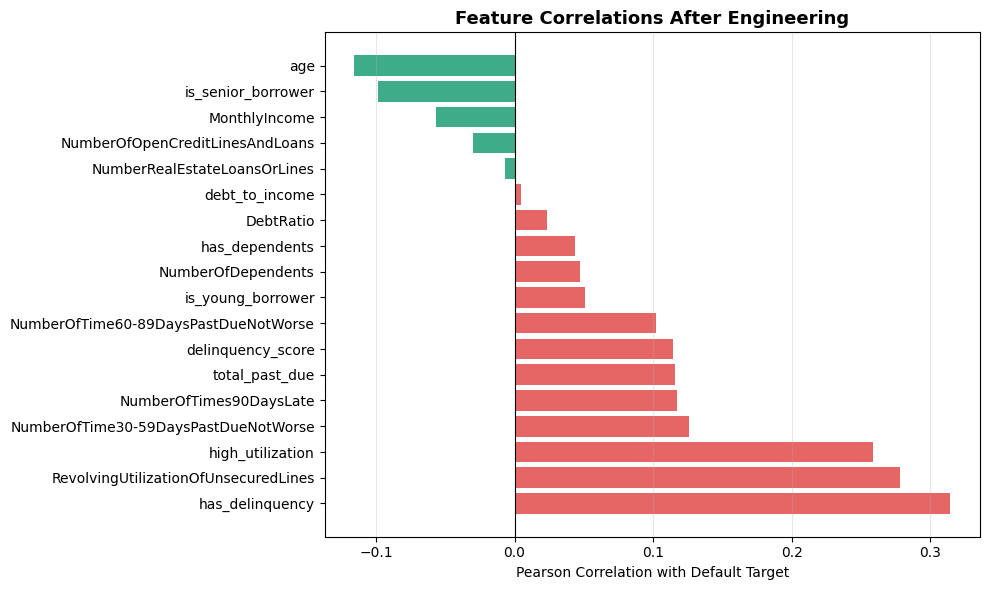

In [9]:
# ── Correlation of ALL features with target ────────────────────
numeric_df = df.select_dtypes(include=[np.number])
correlations = numeric_df.corr()['default_target'].drop('default_target')
correlations = correlations.sort_values(ascending=False)

print('All feature correlations with default_target:')
print(correlations.to_string())

# Chart
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#E24B4A' if x > 0 else '#1D9E75' for x in correlations.values]
ax.barh(correlations.index, correlations.values, color=colors, alpha=0.85)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Pearson Correlation with Default Target')
ax.set_title('Feature Correlations After Engineering', fontsize=13, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/03_correlations_engineered.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Prepare Final Feature Set

In [10]:
# ── Select features for modeling ──────────────────────────────
# Drop the raw delinquency columns since delinquency_score captures them

features_to_drop = [
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTime60-89DaysPastDueNotWorse',
    'NumberOfTimes90DaysLate',
    'NumberOfDependents'  # replaced by has_dependents
]

df_model = df.drop(columns=features_to_drop)

TARGET = 'default_target'
FEATURES = [c for c in df_model.columns if c != TARGET]

X = df_model[FEATURES]
y = df_model[TARGET]

print(f'Feature matrix shape: {X.shape}')
print(f'Target shape: {y.shape}')
print(f'\nFeatures going into model:')
for f in FEATURES:
    print(f'  - {f}')

Feature matrix shape: (149954, 14)
Target shape: (149954,)

Features going into model:
  - RevolvingUtilizationOfUnsecuredLines
  - age
  - DebtRatio
  - MonthlyIncome
  - NumberOfOpenCreditLinesAndLoans
  - NumberRealEstateLoansOrLines
  - delinquency_score
  - debt_to_income
  - is_young_borrower
  - is_senior_borrower
  - high_utilization
  - total_past_due
  - has_delinquency
  - has_dependents


## 5. SMOTE — Fix Class Imbalance

From EDA: 14:1 imbalance (93.3% vs 6.7%). SMOTE synthetically generates new minority class samples by interpolating between existing ones. This prevents the model from being biased toward predicting "no default" every time.

In [11]:
# ── Before SMOTE ───────────────────────────────────────────────
print('Before SMOTE:')
print(f'  Class 0 (no default): {(y==0).sum():,}')
print(f'  Class 1 (default):    {(y==1).sum():,}')
print(f'  Ratio: {(y==0).sum()/(y==1).sum():.1f}:1')

Before SMOTE:
  Class 0 (no default): 139,931
  Class 1 (default):    10,023
  Ratio: 14.0:1


In [12]:
from sklearn.impute import SimpleImputer

# 1. Impute missing values first
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)

# 2. Run SMOTE on the already-clean (imputed) data
smote = SMOTE(random_state=42, k_neighbors=5)
X_resampled, y_resampled = smote.fit_resample(X_imputed, y)

# 3. Print results
print('After SMOTE:')
print(f'  Class 0 (no default): {(y_resampled==0).sum():,}')
print(f'  Class 1 (default):    {(y_resampled==1).sum():,}')
print(f'  Ratio: {(y_resampled==0).sum()/(y_resampled==1).sum():.1f}:1')
print(f'\nNew dataset shape: {X_resampled.shape}')

After SMOTE:
  Class 0 (no default): 139,931
  Class 1 (default):    139,931
  Ratio: 1.0:1

New dataset shape: (279862, 14)


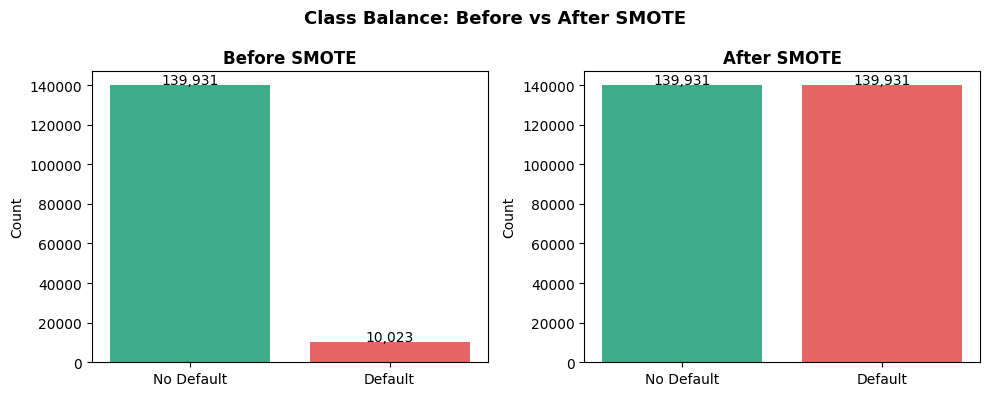

In [13]:
# ── Visualize class balance before vs after ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Before
before_counts = y.value_counts()
axes[0].bar(['No Default', 'Default'], before_counts.values,
            color=['#1D9E75', '#E24B4A'], alpha=0.85)
axes[0].set_title('Before SMOTE', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(before_counts.values):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontsize=10)

# After
after_counts = pd.Series(y_resampled).value_counts()
axes[1].bar(['No Default', 'Default'], after_counts.values,
            color=['#1D9E75', '#E24B4A'], alpha=0.85)
axes[1].set_title('After SMOTE', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Count')
for i, v in enumerate(after_counts.values):
    axes[1].text(i, v + 500, f'{v:,}', ha='center', fontsize=10)

fig.suptitle('Class Balance: Before vs After SMOTE', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/03_smote_balance.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. SQL Analysis
#Using SQLite to explore key business insights from the engineered dataset.

In [15]:
import sqlite3

# Load dataframe into in-memory SQLite database
conn = sqlite3.connect(':memory:')
df_model.to_sql('credit', conn, index=False)

# ── Query 1: Default rate by age group ────────────────────────
print("Default rate by age group:")
q1 = pd.read_sql("""
    SELECT 
        CASE WHEN age < 30 THEN 'Under 30'
             WHEN age BETWEEN 30 AND 49 THEN '30-49'
             WHEN age BETWEEN 50 AND 64 THEN '50-64'
             ELSE '65+' END as age_group,
        ROUND(AVG(default_target) * 100, 2) as default_rate_pct,
        COUNT(*) as total_customers
    FROM credit
    GROUP BY age_group
    ORDER BY default_rate_pct DESC
""", conn)
print(q1.to_string(index=False))

# ── Query 2: Average income by default status ──────────────────
print("\nAverage monthly income by default status:")
q2 = pd.read_sql("""
    SELECT 
        CASE WHEN default_target = 1 THEN 'Defaulted'
             ELSE 'No Default' END as status,
        ROUND(AVG(MonthlyIncome), 2) as avg_income,
        COUNT(*) as total
    FROM credit
    GROUP BY default_target
""", conn)
print(q2.to_string(index=False))

# ── Query 3: High risk customers ──────────────────────────────
print("\nHigh risk customers (delinquency + high utilization):")
q3 = pd.read_sql("""
    SELECT 
        has_delinquency,
        high_utilization,
        ROUND(AVG(default_target) * 100, 2) as default_rate_pct,
        COUNT(*) as total_customers
    FROM credit
    GROUP BY has_delinquency, high_utilization
    ORDER BY default_rate_pct DESC
""", conn)
print(q3.to_string(index=False))

conn.close()

Default rate by age group:
age_group  default_rate_pct  total_customers
 Under 30           11.7300             8820
    30-49            9.0600            57560
    50-64            5.7100            52426
      65+            2.5000            31148

Average monthly income by default status:
    status  avg_income  total
No Default   5923.6600 139931
 Defaulted   5235.1600  10023

High risk customers (delinquency + high utilization):
 has_delinquency  high_utilization  default_rate_pct  total_customers
               1                 1           36.8200            11143
               1                 0           13.8300            19213
               0                 1            8.5400            13986
               0                 0            1.9600           105612


## 6. Save Feature Store

In [16]:
# ── Save original (unbalanced) engineered features ────────────
# Used for evaluation — we evaluate on real distribution, not SMOTE
df_model.to_parquet('../data/processed/credit_features.parquet', index=False)
print(f'Saved credit_features.parquet — shape: {df_model.shape}')

# ── Save SMOTE-balanced dataset for training ───────────────────
X_smote_df = pd.DataFrame(X_resampled, columns=FEATURES)
X_smote_df['default_target'] = y_resampled
X_smote_df.to_parquet('../data/processed/credit_features_smote.parquet', index=False)
print(f'Saved credit_features_smote.parquet — shape: {X_smote_df.shape}')

print('\n✅ Feature store ready. Proceed to Notebook 04 for model training.')

Saved credit_features.parquet — shape: (149954, 15)
Saved credit_features_smote.parquet — shape: (279862, 15)

✅ Feature store ready. Proceed to Notebook 04 for model training.


## 7. Summary

| Step | Detail |
|---|---|
| Raw features | 11 |
| Engineered features | 8 new added |
| Final feature count | 15 |
| Dropped raw columns | 4 (replaced by engineered versions) |
| Class balance before SMOTE | 14:1 |
| Class balance after SMOTE | 1:1 |
| Feature store saved | credit_features.parquet |
| SMOTE dataset saved | credit_features_smote.parquet |

**Key finding**: - `has_delinquency` (0.3144) is the strongest predictor — beating RevolvingUtilization (0.2782)
- Customers with any delinquency default at **22.27%** vs only **2.73%** without — an 8x difference
- High utilization customers default at **21.08%** vs **3.79%** for normal — a 5.6x difference
- Young borrowers (<30) default at **11.73%** — nearly double the overall rate of 6.68%

**Next steps (Week 5 — Model Training)**:
- Load `credit_features_smote.parquet` for training
- Train Logistic Regression, Random Forest, XGBoost, LightGBM
- Evaluate on the original unbalanced `credit_features.parquet` (real distribution)
- Compare AUC-ROC, F1, precision, recall across all 4 models